In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from ISLP import load_data

(a) Split the data set into a training set and a test set.

In [ ]:
df = ISLP.load_data('Carseats')
df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [10]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [4]:
df['Urban'] = df['Urban'].map({'Yes': 1, 'No': 0})
df['US'] = df['US'].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, columns=['ShelveLoc'], drop_first=True)

X = df.drop('Sales', axis=1)
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

(b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

Test MSE of Decision Tree: 4.909815833333334


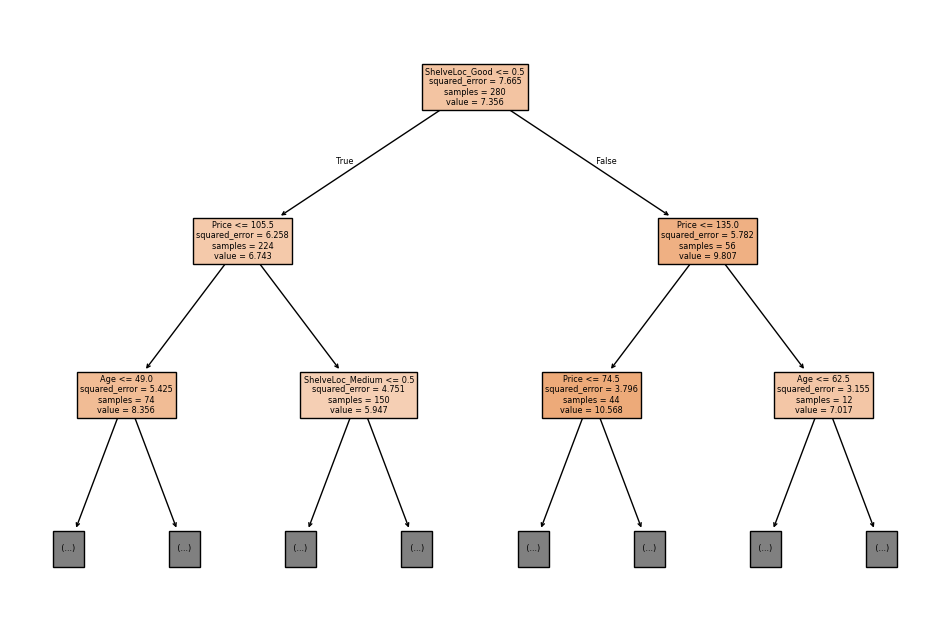

In [12]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE of Decision Tree: {mse}")

plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=X.columns, filled=True, max_depth=2)
plt.show()

The decision tree results indicate that shelf location is the most critical factor affecting sales, as it serves as the splitting criterion for the root node (the first layer). Furthermore, since price appears as the splitting variable for both nodes in the second layer, it suggests that price is likely the second most important determinant of sales.

The Test MSE of roughly 4.0 is considered high because the variance of the original dataset is about 7.7. This means the single decision tree only explains about half of the variability in sales ($R^2 \approx 0.5$).

(c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [15]:
# 1. 取得這棵樹所有可能的 alpha 路徑
path = tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# 2. 使用 CV 找出最佳 alpha
# 這裡建立一個 GridSearch 迴圈
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# 簡單的手動 CV (或使用 GridSearchCV)
# 這裡示範用內建 cross_val_score 找分數最高的 alpha
alpha_scores = [cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean() for clf in clfs]

# 找出最佳 alpha (分數越高越好，因為是 negative MSE)
best_alpha = ccp_alphas[np.argmax(alpha_scores)]
print(f"Optimal alpha: {best_alpha}")

# 3. 用最佳 alpha 訓練最終修剪樹
pruned_tree = DecisionTreeRegressor(random_state=0, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)

print(f"Pruned Tree Test MSE: {mse_pruned:.4f}")

Optimal alpha: 0.03512678890305898
Pruned Tree Test MSE: 4.1891


Yes, pruning the tree improved the model's performance. The test MSE decreased from 4.91 (full tree) to 4.19 (pruned tree), indicating that the pruned tree generalizes better to unseen data.

(d) Use the bagging approach in order to analyze this data. What
test MSE do you obtain? Use the feature_importance_ values to
determine which variables are most important.

In [25]:
# max_features=None 代表使用所有特徵 (即 Bagging)
bagging_reg = RandomForestRegressor(max_features=None, random_state=0, n_estimators=100)
bagging_reg.fit(X_train, y_train)

y_pred_bag = bagging_reg.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)

print(f"Bagging Test MSE: {mse_bag:.4f}")

# Feature Importance
importances = pd.Series(bagging_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nMost Important Variables (Bagging):")
print(importances.head(5))

Bagging Test MSE: 2.4859

Most Important Variables (Bagging):
Price             0.324952
ShelveLoc_Good    0.186939
Age               0.118973
CompPrice         0.106664
Advertising       0.080760
dtype: float64


(e) Use random forests to analyze this data. What test MSE do
you obtain? Use the feature_importance_ values to determine
which variables are most important. Describe the effect of m, the
number of variables considered at each split, on the error rate
obtained.

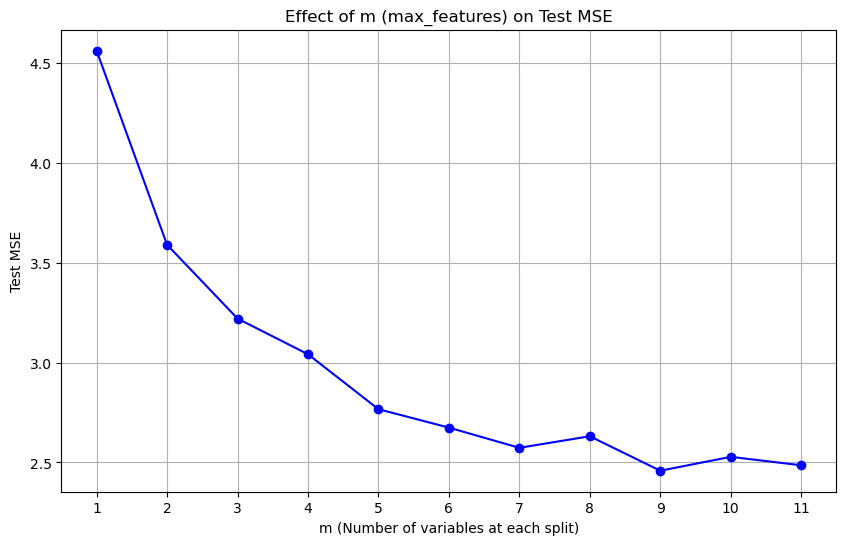

最小 MSE 發生在 m=9，數值為: 2.4586

Most Important Variables (Best Model):
Price             0.321496
ShelveLoc_Good    0.180412
Age               0.117522
CompPrice         0.107764
Advertising       0.087205
dtype: float64


In [29]:
import matplotlib.pyplot as plt

# 1. 準備容器來存不同 m 的 MSE
mse_values = []
p = X_train.shape[1]  # 總特徵數量 (應該是 10 或 11)
m_range = range(1, p + 1) # 測試從 1 到 所有特徵

# 2. 跑迴圈
for m in m_range:
    rf_reg = RandomForestRegressor(max_features=m, random_state=0, n_estimators=100)
    rf_reg.fit(X_train, y_train)
    
    y_pred_rf = rf_reg.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_rf)
    mse_values.append(mse)
    
    # Optional: 只印出數字給自己確認
    # print(f"m={m}, MSE={mse:.4f}")

# 3. 畫出 MSE 隨 m 變化的折線圖
plt.figure(figsize=(10, 6))
plt.plot(m_range, mse_values, marker='o', linestyle='-', color='b')
plt.title('Effect of m (max_features) on Test MSE')
plt.xlabel('m (Number of variables at each split)')
plt.ylabel('Test MSE')
plt.grid(True)
plt.xticks(m_range) # 確保 x 軸刻度是整數
plt.show()

# 4. 印出 Feature Importance (通常只印最佳的那個 m，不需要印 10 次)
best_m = m_range[np.argmin(mse_values)]
print(f"最小 MSE 發生在 m={best_m}，數值為: {min(mse_values):.4f}")

# 用最佳的 m 再跑一次抓 Importance
best_rf = RandomForestRegressor(max_features=best_m, random_state=0, n_estimators=100)
best_rf.fit(X_train, y_train)
print("\nMost Important Variables (Best Model):")
print(pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(5))

(f) Now analyze the data using BART, and report your results.

In [23]:
try:
    from ISLP.bart import BART
    
    # BART 在 ISLP 的實作通常不需要太複雜的調參
    X_train = X_train.astype(float)
    X_test = X_test.astype(float)
    
    bart_model = BART(random_state=0, burnin=500, ndraw=1000)
    bart_model.fit(X_train, y_train)
    
    y_pred_bart = bart_model.predict(X_test)
    mse_bart = mean_squared_error(y_test, y_pred_bart)
    print(f"(f) BART Test MSE: {mse_bart:.4f}")
    
except ImportError:
    print("(f) BART 需要 ISLP 完整環境或其他 BART 套件 (如 bartpy)。")
    print("若無法執行，可提及 BART 通常能提供與 Random Forest 相似或更好的表現。")

(f) BART Test MSE: 1.2380
